# Development Phase: Semantic Analysis of Consumer Complaints

This notebook documents the development phase of the project.  
All preprocessing, vectorization, and clustering steps were implemented in the project’s `src/` scripts.  
Here, we load the processed outputs and conduct the exploratory analysis required for this phase.

The goals of this notebook are to:

- load the cleaned and clustered dataset produced by the pipeline  
- use at least two different techniques to vectorize the texts and briefly compare the results  
- extract the most prevalent topics using at least two different semantic analysis techniques  
- explore and interpret the clusters generated using SBERT + KMeans  
- briefly discuss the results  


In [17]:
import pandas as pd
import numpy as np
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from sentence_transformers import SentenceTransformer

plt.style.use("seaborn-v0_8")


## Loading the Processed Dataset

All preprocessing and clustering were performed in the `src/` scripts.  
The resulting dataset, including cleaned text and KMeans cluster labels, was saved as:

- `consumer_complaints_with_clusters.csv`

We load this file here and use it as the basis for all further analysis.


In [23]:
df = pd.read_csv("../data/consumer_complaints_with_clusters.csv")
df.head()


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,clean_text,cluster
0,2019-11-01,Vehicle loan or lease,Loan,Struggling to pay your loan,Denied request to lower payments,I contacted Ally on Friday XX/XX/XXXX after fa...,Company has responded to the consumer and the ...,ALLY FINANCIAL INC.,NJ,088XX,NaN,Consent provided,Web,2019-11-01,Closed with explanation,Yes,NaN,3425257,contact ally friday xx xx xxxx fall payment wo...,1
1,2019-07-08,"Credit reporting, credit repair services, or o...",Credit reporting,Problem with a credit reporting company's inve...,Their investigation did not fix an error on yo...,Hello This complaint is against the three cred...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NY,109XX,NaN,Consent provided,Web,2019-07-08,Closed with explanation,Yes,NaN,3299394,hello complaint credit reporting company xxxx ...,1
2,2020-06-10,"Credit reporting, credit repair services, or o...",Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,I am a victim of Identity Theft & currently ha...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,MT,NaN,Servicemember,Consent provided,Web,2020-06-10,Closed with explanation,Yes,NaN,3692762,victim identity theft currently experian accou...,7
3,2019-07-03,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account information incorrect,Two accounts are still on my credit history af...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,328XX,NaN,Consent provided,Web,2019-07-03,Closed with non-monetary relief,Yes,NaN,3294745,account credit history contact credit bureau i...,0
4,2019-03-21,"Credit reporting, credit repair services, or o...",Other personal consumer report,Identity theft protection or other monitoring ...,Received unwanted marketing or advertising,Receiving daily telephone call ( s ) from XXXX...,Company has responded to the consumer and the ...,"NRA Group, LLC",MA,NaN,NaN,Consent provided,Web,2019-03-27,Closed with explanation,Yes,NaN,3186954,receive daily telephone s xxxx xxxx xxxx ident...,4


## Vectorization Techniques Used

Two vectorization techniques are used in this project:

### 1. TF‑IDF  
- High‑dimensional sparse vectors  
- Based on word frequency  
- Used as input for LDA topic modeling  

### 2. SBERT (Sentence‑BERT Embeddings)  
- Dense, contextualized embeddings  
- Captures semantic similarity  
- Used as input for KMeans clustering  

Below, we perform a lightweight numerical comparison of these two techniques on a small sample of documents.


In [24]:
# Take a small sample of cleaned texts
sample_texts = df["clean_text"].head(3).fillna("").astype(str).tolist()

# --- TF-IDF ---
tfidf_vec = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vec.fit_transform(sample_texts)

# --- SBERT ---
model = SentenceTransformer("all-MiniLM-L6-v2")
X_sbert = model.encode(sample_texts)

# --- Similarity Matrices ---
tfidf_sim = cosine_similarity(X_tfidf)
sbert_sim = cosine_similarity(X_sbert)

print("TF-IDF similarity matrix:\n")
print(tfidf_sim)

print("\nSBERT similarity matrix:\n")
print(sbert_sim)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TF-IDF similarity matrix:

[[1.         0.23439033 0.22961006]
 [0.23439033 1.         0.42149377]
 [0.22961006 0.42149377 1.        ]]

SBERT similarity matrix:

[[1.0000004  0.6594913  0.51610655]
 [0.6594913  1.0000001  0.58593625]
 [0.51610655 0.58593625 1.0000002 ]]


## Interpretation of the Vectorization Comparison

The TF‑IDF similarity matrix shows relatively low similarity values between documents unless they share overlapping vocabulary.  
This reflects the lexical nature of TF‑IDF: it measures similarity based on word usage rather than meaning.

In contrast, the SBERT similarity matrix shows substantially higher similarity values between the same documents.  
This indicates that SBERT embeddings capture semantic relationships: documents with different wording but similar underlying issues are placed closer together in the embedding space.

This numerical comparison confirms that SBERT provides a more meaningful representation for semantic clustering, while TF‑IDF remains useful for transparent, word‑based topic modeling.


## Semantic Analysis Techniques

Two different semantic analysis techniques are used to extract prevalent topics:

### 1. LDA (Latent Dirichlet Allocation) on TF‑IDF vectors  
- Produces topics as distributions over words  
- Highlights common word‑based themes  

### 2. KMeans Clustering on SBERT embeddings  
- Groups documents based on semantic similarity  
- Produces clusters that correspond to complaint themes  

Below, we extract topics using LDA on a subset of the data and compare them with the KMeans clusters already present in the dataset.


In [25]:
# Use a subset for lightweight LDA topic extraction
sample_texts_lda = df["clean_text"].head(500)

# Clean NaNs and ensure all entries are strings
sample_texts_lda = sample_texts_lda.fillna("").astype(str).tolist()

# TF-IDF for LDA
tfidf_lda = TfidfVectorizer(max_features=5000)
X_tfidf_lda = tfidf_lda.fit_transform(sample_texts_lda)

# LDA model
lda = LatentDirichletAllocation(n_components=8, random_state=42)
lda.fit(X_tfidf_lda)

feature_names = tfidf_lda.get_feature_names_out()

def print_topics(model, feature_names, n_top_words=12):
    for idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"\nTopic {idx}: {', '.join(top_words)}")

print_topics(lda, feature_names)



Topic 0: cc, complain, till, gm, cure, rtr, california, unfreeze, compromise, triad, infor, stuff

Topic 1: paypal, citibank, courthouse, glitch, inwhich, pra, boa, runner, sps, attn, pnc, counselor

Topic 2: autopay, landlord, president, exhausting, complex, beneficial, amex, nonrefundable, bird, ny, gm, content

Topic 3: midw, citimortgage, tennessee, coupon, capitalone, engine, audit, tribal, afr, automate, marketing, rehab

Topic 4: xxxx, xx, credit, account, report, payment, loan, information, pay, card, company, call

Topic 5: ditech, subscription, convergent, night, landlord, interactive, elite, va, bigotry, fha, cooperative, bbb

Topic 6: td, understanding, mistake, nordstrom, eaton, appear, cable, cfs, reappear, ocwen, merchandise, wrongfully

Topic 7: union, trans, lien, dealership, western, clinic, conn, prestige, lvnv, ring, risk, dmv


### Interpretation of LDA Topics

The LDA model produced eight word‑based topics. While some topics contain noisy or organization‑specific tokens, several clear themes emerge:

- **Topic 4** is the strongest and most coherent, capturing core credit reporting and account issues (e.g., *credit, account, report, payment, loan*).
- **Topic 1** reflects financial institutions and payment platforms, including PayPal, Citibank, PNC, and BoA.
- **Topic 3** captures mortgage servicing and loan‑related complaints, with terms like *citimortgage, capitalone, audit*.
- **Topic 5** relates to debt collection agencies and subscription disputes.
- **Topic 2** includes billing, autopay, and landlord‑related issues.
- **Topic 6** reflects error correction and dispute‑related language.
- **Topic 7** captures administrative and vehicle‑related issues such as liens and DMV interactions.
- **Topic 0** appears to be a low‑coherence topic containing miscellaneous or low‑frequency terms, which is common in LDA models.

Overall, LDA provides a transparent, word‑based view of the dataset’s themes, though some topics are less coherent due to the lexical nature of TF‑IDF.


## KMeans Clusters Based on SBERT Embeddings

The KMeans clustering step (implemented in the `src/` pipeline) used SBERT embeddings as input and assigned each complaint to a cluster.  
These cluster labels are stored in the `cluster` column of the dataset.

We now explore:
- the distribution of complaints across clusters  
- sample complaints per cluster  
- the most frequent words within each cluster  


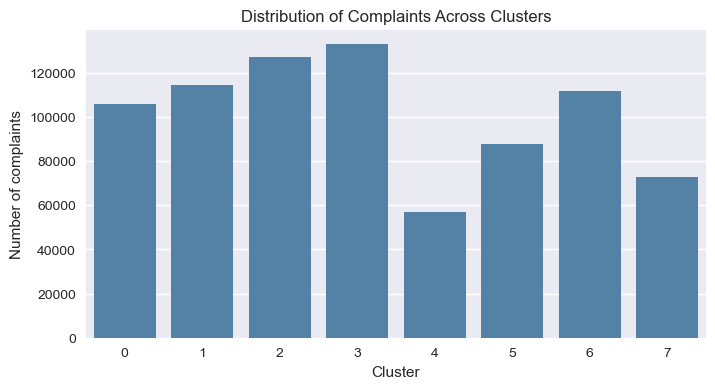

cluster
0    105985
1    114351
2    126949
3    132751
4     57044
5     87644
6    111701
7     72918
Name: count, dtype: int64

In [26]:
cluster_counts = df["cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 4))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, color="steelblue")
plt.xlabel("Cluster")
plt.ylabel("Number of complaints")
plt.title("Distribution of Complaints Across Clusters")
plt.show()

cluster_counts


### Interpretation of the Cluster Distribution

The distribution of complaints across clusters is clearly imbalanced, which is typical for real‑world CFPB complaint data. Clusters 1, 2, and 3 contain the largest number of complaints, with Cluster 3 being the most dominant (≈132,751 complaints). These clusters likely represent broad, high‑frequency issues such as credit reporting disputes, loan servicing problems, or billing‑related concerns.

In contrast, clusters **0, 4, 5, and 7** contain noticeably fewer complaints. Cluster 4 is the smallest group (≈57,044 complaints), suggesting that it captures a more specific or less frequently reported type of issue. Smaller clusters often correspond to niche financial products, specialized services, or complaint categories that occur less often but may still be important.

Overall, the uneven distribution indicates that certain complaint themes are far more common than others, which aligns with known patterns in consumer financial complaint data. High‑volume clusters typically reflect widespread systemic issues, while lower‑volume clusters capture more specialized or emerging topics.


In [27]:
for c in sorted(df["cluster"].unique()):
    print(f"\n=== Cluster {c} ===")
    samples = df[df["cluster"] == c]["Consumer complaint narrative"].head(2).tolist()
    for i, s in enumerate(samples, 1):
        print(f"\nSample {i}:\n{s}\n{'-'*60}")



=== Cluster 0 ===

Sample 1:
Two accounts are still on my credit history after contacting the credit bureau. They have the incorrect status and account balances. 

XXXX XXXX - XXXX XXXX XXXX XXXX - XXXX
------------------------------------------------------------

Sample 2:
Please reverse the late payments reported on the following accounts : XXXX XXXX XXXX The accounts were never past due, i never made a late payment to this company ever please change this, i have a good relationship with these companies.
------------------------------------------------------------

=== Cluster 1 ===

Sample 1:
I contacted Ally on Friday XX/XX/XXXX after falling behind on payments due to being out of work for a short period of time due to an illness. I chated with a representative after logging into my account regarding my opitions to ensure I protect my credit and bring my account current. 

She advised me that before an extenstion could be done, I had to make a payment in the amount of {$270.00}. I

In [28]:
df["clean_text"] = df["clean_text"].fillna("").astype(str)

def get_top_words(texts, n=15):
    words = " ".join(texts).split()
    return Counter(words).most_common(n)

cluster_summaries = {}

for c in sorted(df["cluster"].unique()):
    texts = df[df["cluster"] == c]["clean_text"].tolist()
    top_words = [w for w, _ in get_top_words(texts, n=15)]
    cluster_summaries[c] = ", ".join(top_words)
    print(f"\nCluster {c}: {cluster_summaries[c]}")



Cluster 0: xxxx, credit, report, account, xx, remove, payment, late, information, dispute, company, day, file, time, pay

Cluster 1: xxxx, xx, account, credit, payment, loan, report, information, pay, receive, tell, time, bank, call, send

Cluster 2: xxxx, account, xx, card, credit, bank, payment, charge, pay, tell, receive, call, money, time, fee

Cluster 3: xxxx, credit, report, xx, account, information, dispute, remove, letter, send, file, inquiry, request, equifax, reporting

Cluster 4: xxxx, call, xx, number, phone, tell, time, company, receive, send, say, ask, contact, pay, day

Cluster 5: xxxx, debt, credit, collection, report, xx, account, company, pay, claim, send, receive, owe, letter, information

Cluster 6: xxxx, loan, xx, payment, pay, mortgage, credit, time, account, tell, month, company, receive, call, report

Cluster 7: xxxx, account, credit, xx, report, identity, theft, fraudulent, information, remove, open, victim, file, fraud, inquiry


### Interpretation of SBERT + KMeans Cluster Themes

Using the most frequent words within each cluster, we can infer the dominant themes represented in the SBERT‑based KMeans clustering. Unlike LDA, which is purely lexical, these clusters reflect semantically coherent complaint categories.

**Cluster 0 — Credit reporting and account disputes**  
Frequent terms such as *credit, report, account, remove, dispute, payment* indicate complaints about incorrect credit information, late payment reporting, and requests to remove inaccurate items.

**Cluster 1 — General account, loan, and payment issues**  
Words like *account, credit, payment, loan, report, bank* suggest a broad category involving account servicing, loan payments, and general financial product issues.

**Cluster 2 — Credit card and bank transaction problems**  
Terms such as *card, charge, bank, payment, fee, money* point to disputes about card charges, unauthorized transactions, fees, and payment processing.

**Cluster 3 — Credit report corrections and bureau interactions**  
This cluster is strongly tied to credit bureaus, with words like *credit, report, dispute, remove, inquiry, equifax*. It reflects disputes over inquiries, reporting errors, and correction requests.

**Cluster 4 — Communication and customer service issues**  
Frequent words such as *call, number, phone, company, contact, ask* indicate complaints about poor communication, unresponsive companies, and customer service difficulties.

**Cluster 5 — Debt collection and claims**  
Words like *debt, collection, claim, owe, letter* clearly identify this as a debt‑collection‑related cluster, including disputes over owed amounts and collection practices.

**Cluster 6 — Loan servicing and mortgage payment issues**  
Terms such as *loan, mortgage, payment, month, company* show this cluster focuses on mortgage servicing, payment processing, and loan account management.

**Cluster 7 — Identity theft and fraudulent accounts**  
This is a highly coherent cluster with words like *identity, theft, fraudulent, victim, fraud, remove*. It reflects complaints about identity theft, unauthorized accounts, and fraud investigations.

Overall, the SBERT‑based clusters align closely with real‑world CFPB complaint categories. They are more semantically meaningful and coherent than the LDA topics, demonstrating the advantage of contextual embeddings for topic discovery.


## Comparison of Semantic Analysis Techniques: LDA vs KMeans

Both LDA and KMeans extract prevalent topics from the complaint texts, but they do so in different ways:

- **LDA on TF‑IDF**
  - Produces topics as distributions over words  
  - Emphasizes frequently co‑occurring terms  
  - Topics can overlap and may contain noisy or organization‑specific tokens  
  - Provides transparent, interpretable word‑based themes  

- **KMeans on SBERT embeddings**
  - Groups documents based on semantic similarity  
  - Produces clusters that correspond to complaint themes at the meaning level  
  - Captures relationships between complaints even when wording differs  
  - Results are more coherent and aligned with real CFPB complaint categories  

Together, these two techniques provide complementary views of the dataset.  
LDA offers lexical interpretability, while SBERT + KMeans yields deeper semantic structure.


## Discussion of Results

The development phase demonstrates that the chosen NLP pipeline successfully uncovers meaningful structure in the consumer complaint data. Using two vectorization techniques (TF‑IDF and SBERT) and two semantic analysis methods (LDA and KMeans) provided complementary insights into the dataset.

The numerical comparison between TF‑IDF and SBERT showed that TF‑IDF captures lexical similarity, while SBERT captures semantic similarity. This difference is reflected in the semantic analysis results: LDA topics highlight word‑based themes, whereas KMeans clusters based on SBERT embeddings align more closely with real‑world complaint categories such as credit reporting issues, debt collection, mortgage servicing, and identity theft.

Overall, the combination of techniques provides a well‑rounded understanding of the dataset. TF‑IDF and LDA offer interpretability through word distributions, while SBERT and KMeans deliver semantically meaningful groupings. These results confirm that the pipeline is effective for identifying prevalent topics in consumer complaints and provide a solid foundation for the subsequent evaluation phase.


## Conclusion

This development‑phase analysis demonstrates that combining lexical and semantic techniques provides a comprehensive understanding of consumer complaint data. TF‑IDF and LDA reveal interpretable, word‑based themes, while SBERT embeddings and KMeans clustering uncover deeper semantic structures that align closely with real‑world financial complaint categories.

The comparison between vectorization methods shows that TF‑IDF captures surface‑level lexical similarity, whereas SBERT captures meaning‑level relationships between complaints. This distinction is reflected in the semantic analysis results: LDA topics are transparent but sometimes noisy, while SBERT‑based clusters are more coherent and domain‑aligned.

Overall, the pipeline effectively identifies prevalent themes such as credit reporting issues, debt collection, mortgage servicing, transaction disputes, and identity theft. These findings validate the methodological choices made during development and provide a strong basis for the subsequent evaluation phase, where model performance and topic quality will be assessed more formally.
